# The Impacts of Working Remotely and in an Office

This notebook analyses the survey dataset (1,000 respondents) covering productivity, health impacts, flexibility, social contact, focus, and work preferences across different work arrangements.

**Dataset:** `The Impacts of Working Remotely and in an Office Survey.csv`  
**Respondents:** 1,000  
**Columns:** 16 (6 demographic + 10 survey questions)

---
## 1. Setup & Data Loading

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('The Impacts of Working Remotely and in an Office Survey.csv')

# Ordered categories for consistent chart ordering
age_order = ['18\u201324', '25\u201334', '35\u201344', '45\u201354', '55+']
exp_order = ['0\u20132 years', '3\u20135 years', '6\u201310 years', '11\u201320 years', '20+ years']
arr_order = ['Fully Remote', 'Hybrid', 'Fully In-Office']

df['Age Group'] = pd.Categorical(df['Age Group'], categories=age_order, ordered=True)
df['Years of Experience'] = pd.Categorical(df['Years of Experience'], categories=exp_order, ordered=True)
df['Current Work Arrangement'] = pd.Categorical(df['Current Work Arrangement'], categories=arr_order, ordered=True)

print(f'Shape: {df.shape}  |  Missing values: {df.isnull().sum().sum()}')

Shape: (1000, 16)  |  Missing values: 0


---
## 2. Dataset Overview

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                                                                                                   Non-Null Count  Dtype   
---  ------                                                                                                   --------------  -----   
 0   Response ID                                                                                              1000 non-null   int64   
 1   Age Group                                                                                                1000 non-null   category
 2   Gender                                                                                                   1000 non-null   object  
 3   Industry                                                                                                 1000 non-null   object  
 4   Years of Experience                                                            

In [3]:
display(df.head(10))

,Response ID,Age Group,Gender,Industry,Years of Experience,Current Work Arrangement,Have you ever experienced working from home?,Do you think that working from home increases your work productivity?,Do you think that working from home prevents you from going out?,Do you think that working from home gives you more flexibility?,Do you think that working from home saves you more time?,"Which work type has the potential to cause you physical problems, such as the neck, back, and leg pain?","Which work type has the potential to cause mental disorders, such as stress, anxiety, and depression?",Do you think that working from home prevents you from getting in contact with people?,Which work type keeps you focused while working?,Which work type do you prefer the most?
0,1,45–54,Male,Government,11–20 years,Fully In-Office,Yes,No,No,Yes,Yes,Working from home,Working in an office,No,Working in an office,Working in an office
1,2,25–34,Male,Education,6–10 years,Hybrid,Yes,Yes,Yes,Yes,Yes,Working from home,Working from home,Yes,Working in an office,A mixed mode of working
2,3,45–54,Male,Other,3–5 years,Fully In-Office,No,No,No,Yes,No,Working in an office,Working from home,Yes,Working in an office,Working from home
3,4,35–44,Male,Retail/Hospitality,11–20 years,Fully Remote,Yes,No,Yes,Yes,No,Working from home,Working in an office,Yes,Working in an office,A mixed mode of working
4,5,18–24,Female,Technology,0–2 years,Hybrid,Yes,Yes,Yes,Yes,Yes,Working in an office,Working from home,No,Working from home,A mixed mode of working
5,6,55+,Male,Other,11–20 years,Fully Remote,Yes,Yes,Yes,Yes,No,Working from home,Working from home,Yes,Working in an office,Working from home
6,7,45–54,Female,Education,6–10 years,Hybrid,Yes,Yes,Yes,Yes,No,Working from home,Working from home,Yes,Working from home,A mixed mode of working
7,8,45–54,Male,Technology,0–2 years,Fully Remote,Yes,Yes,Yes,Yes,No,Working from home,Working from home,Yes,Working from home,A mixed mode of working
8,9,18–24,Female,Technology,0–2 years,Fully Remote,Yes,Yes,Yes,Yes,No,Working from home,Working from home,Yes,Working in an office,Working from home
9,10,25–34,Male,Retail/Hospitality,11–20 years,Hybrid,Yes,No,Yes,Yes,No,Working from home,Working in an office,Yes,Working in an office,A mixed mode of working


---
## 3. Demographic Breakdown

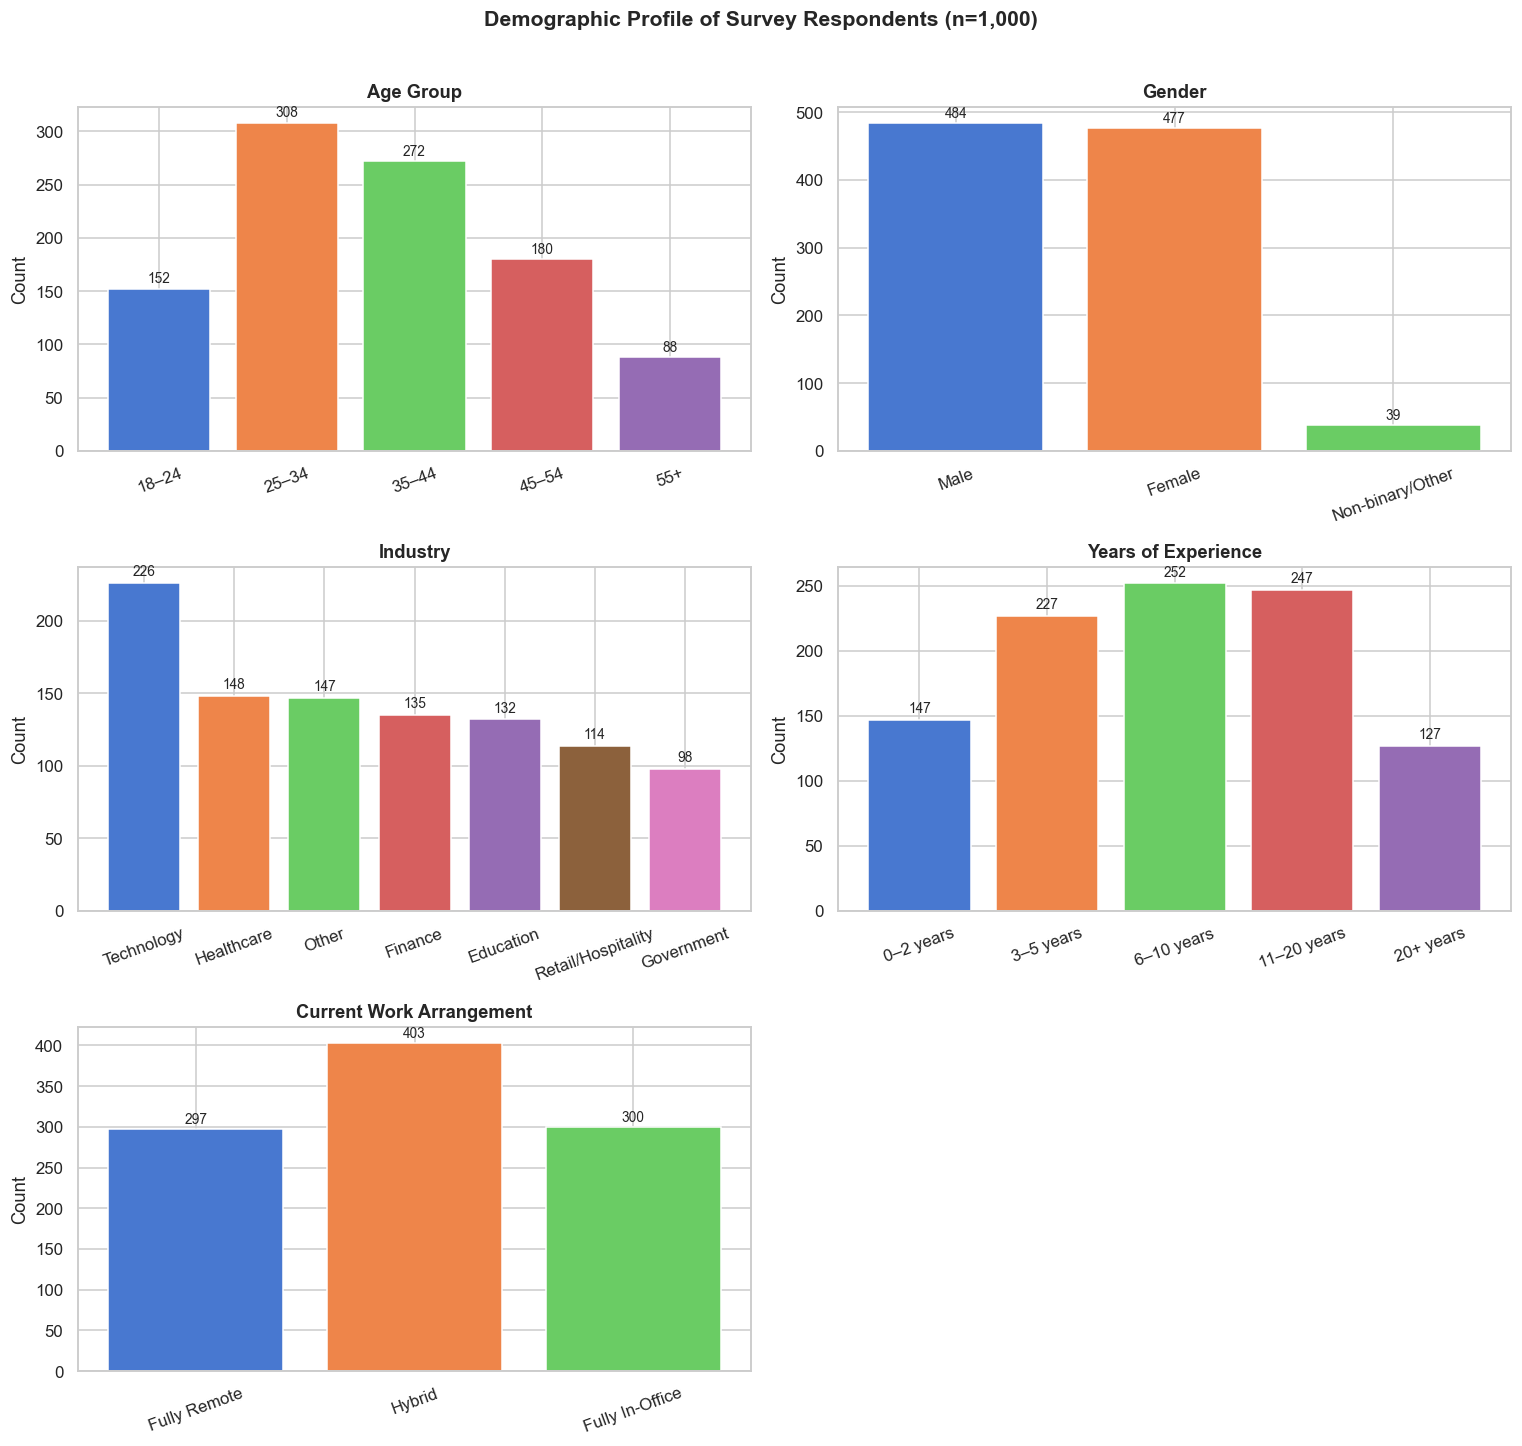

In [4]:
demo_cols = [
    ('Age Group',               age_order),
    ('Gender',                  None),
    ('Industry',                None),
    ('Years of Experience',     exp_order),
    ('Current Work Arrangement', arr_order),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 13))
axes = axes.flatten()

for ax, (col, order) in zip(axes, demo_cols):
    counts = df[col].value_counts()
    if order:
        counts = counts.reindex([o for o in order if o in counts.index])
    bars = ax.bar(counts.index, counts.values, color=sns.color_palette('muted', len(counts)))
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=20)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
                f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=9)

axes[-1].set_visible(False)
fig.suptitle('Demographic Profile of Survey Respondents (n=1,000)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Survey Question Analysis

Each of the 10 survey questions is shown as a bar chart (count) and a pie chart (percentage).

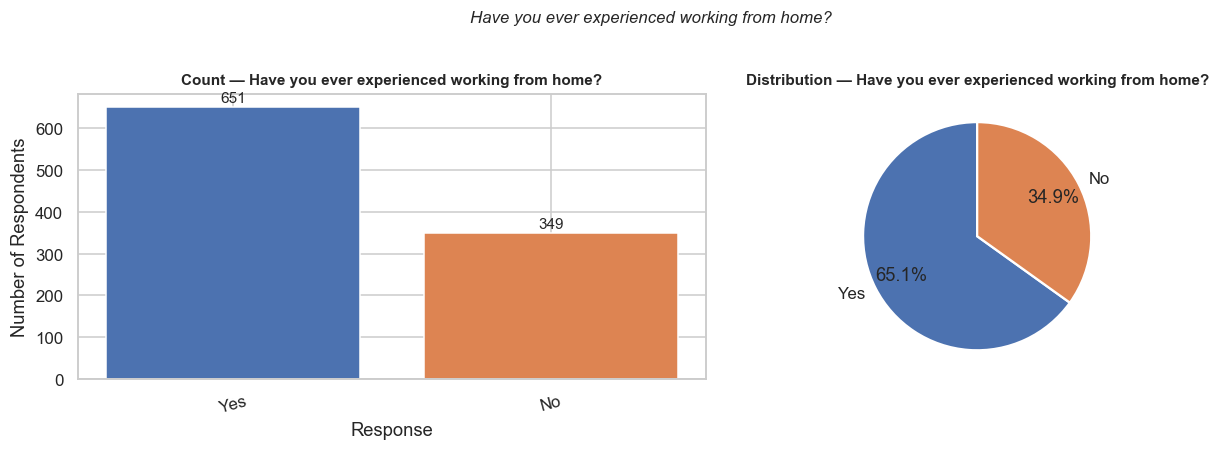

Have you ever experienced working from home?
Yes    651
No     349 



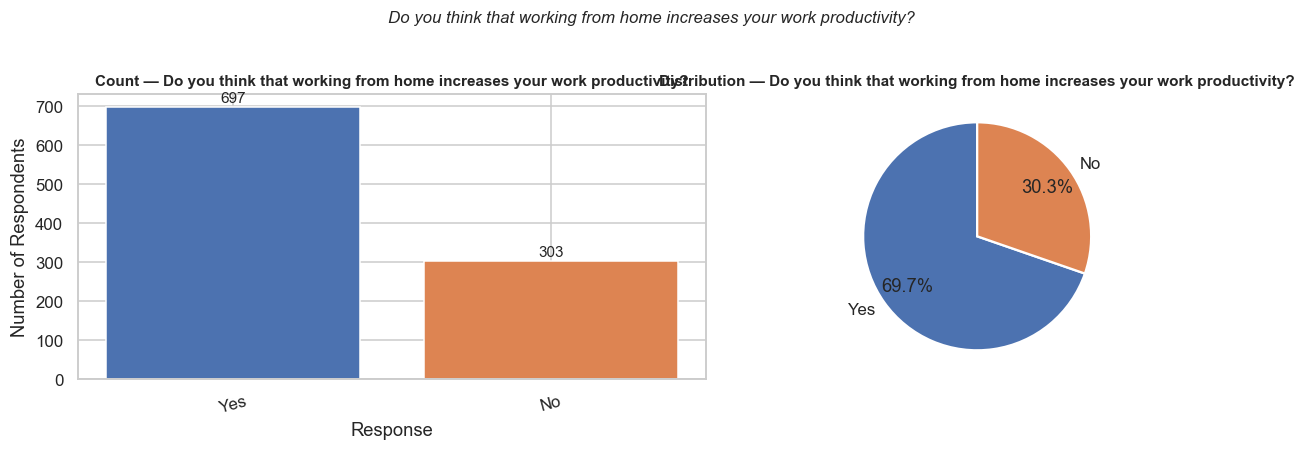

Do you think that working from home increases your work productivity?
Yes    697
No     303 



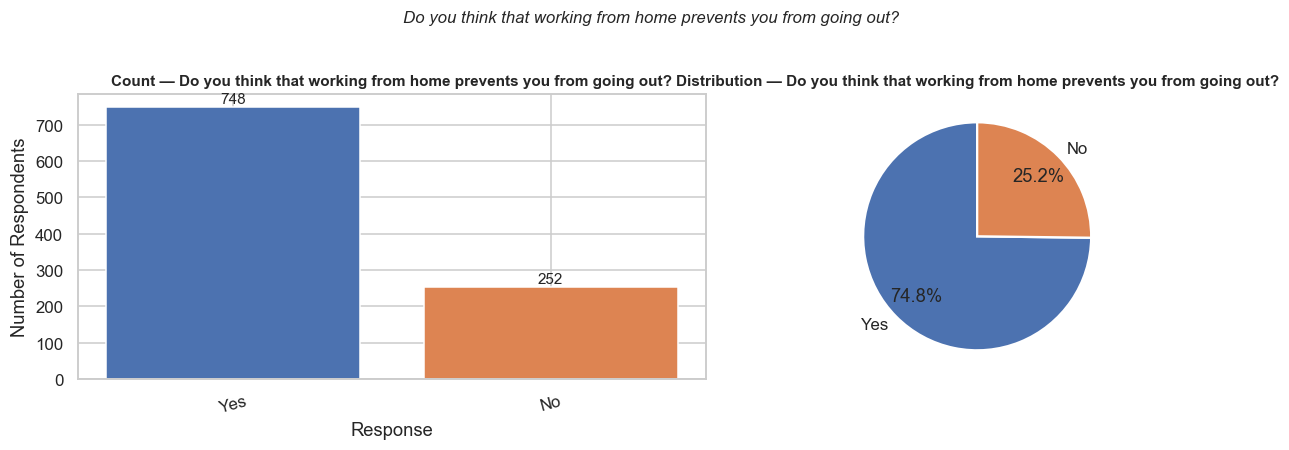

Do you think that working from home prevents you from going out?
Yes    748
No     252 



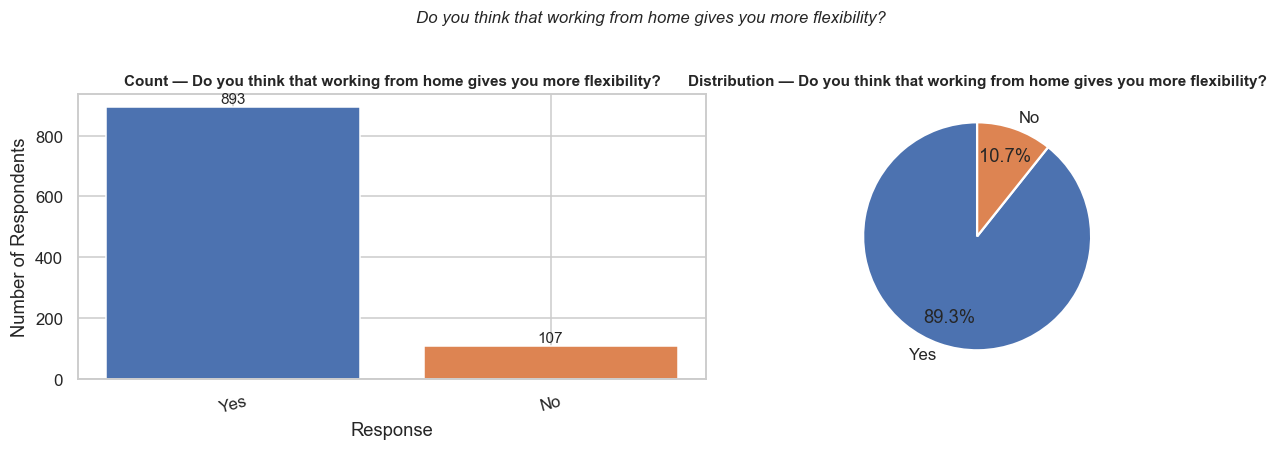

Do you think that working from home gives you more flexibility?
Yes    893
No     107 



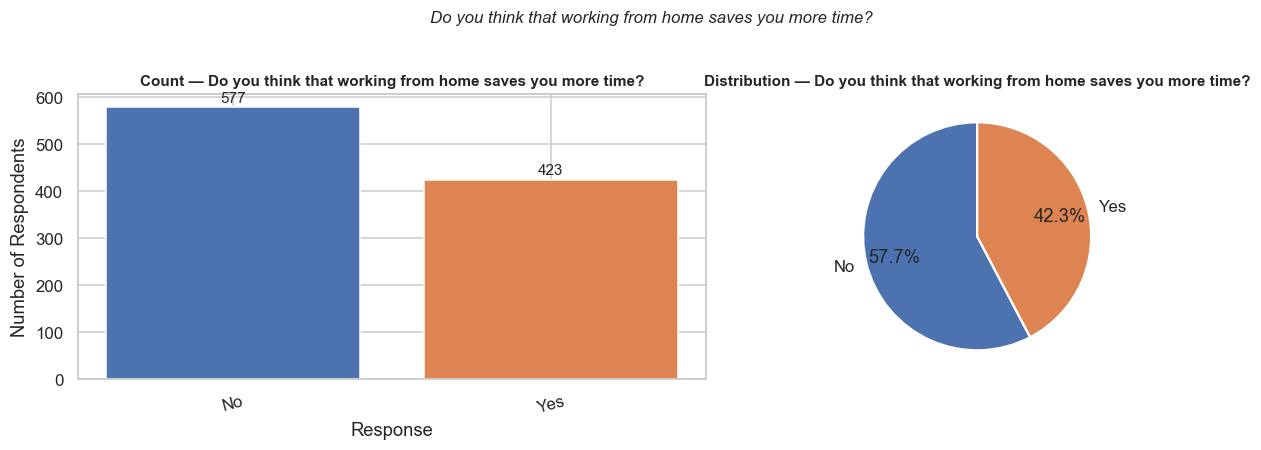

Do you think that working from home saves you more time?
No     577
Yes    423 



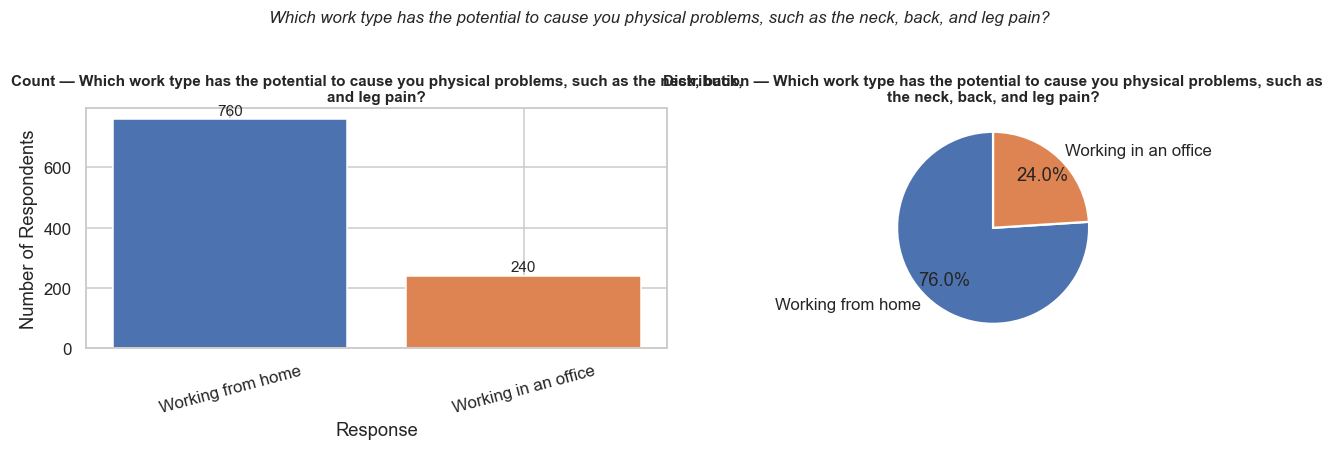

Which work type has the potential to cause you physical problems, such as the neck, back, and leg pain?
Working from home       760
Working in an office    240 



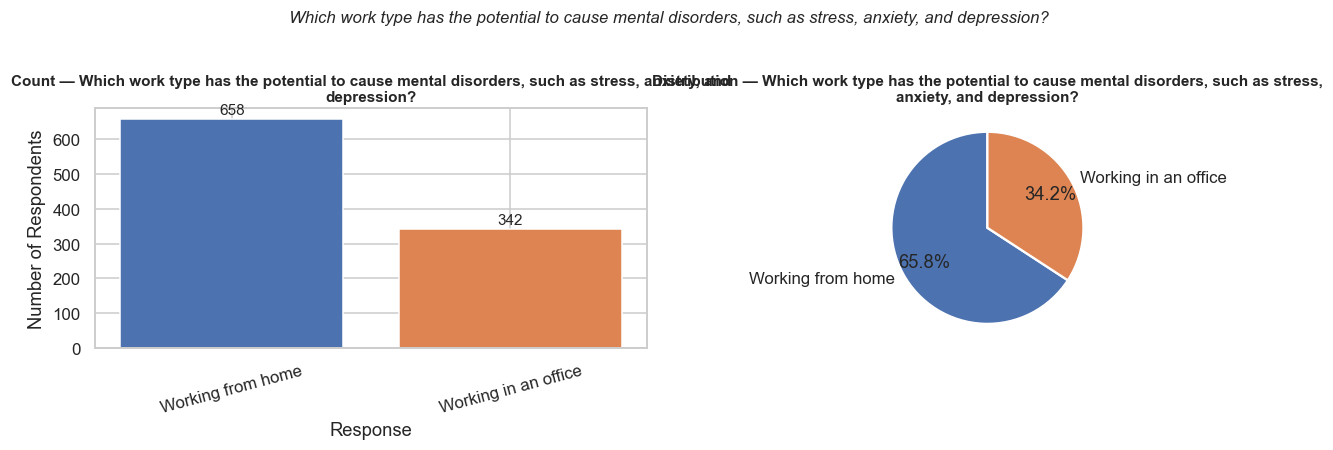

Which work type has the potential to cause mental disorders, such as stress, anxiety, and depression?
Working from home       658
Working in an office    342 



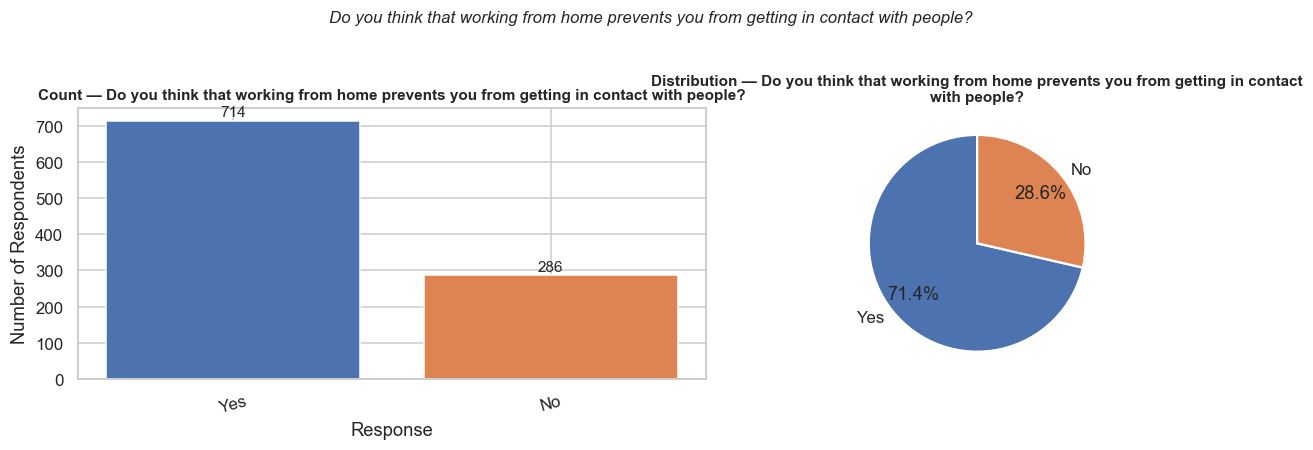

Do you think that working from home prevents you from getting in contact with people?
Yes    714
No     286 



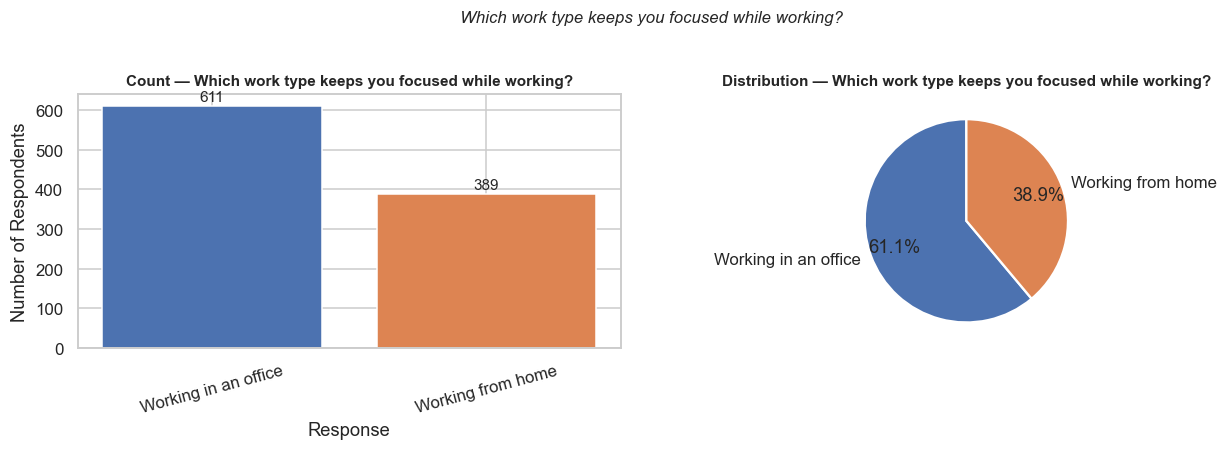

Which work type keeps you focused while working?
Working in an office    611
Working from home       389 



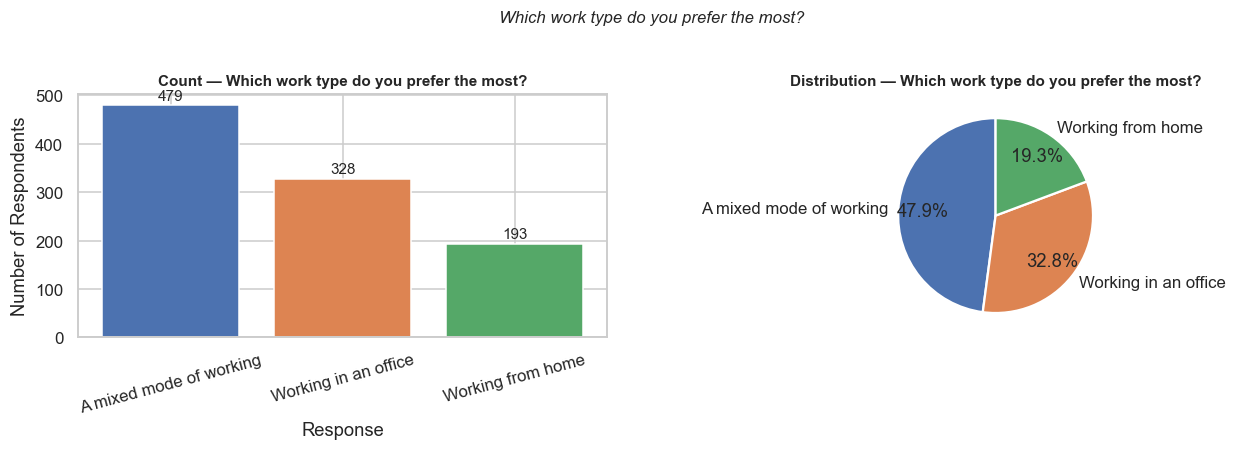

Which work type do you prefer the most?
A mixed mode of working    479
Working in an office       328
Working from home          193 



In [5]:
survey_cols = [
    'Have you ever experienced working from home?',
    'Do you think that working from home increases your work productivity?',
    'Do you think that working from home prevents you from going out?',
    'Do you think that working from home gives you more flexibility?',
    'Do you think that working from home saves you more time?',
    'Which work type has the potential to cause you physical problems, such as the neck, back, and leg pain?',
    'Which work type has the potential to cause mental disorders, such as stress, anxiety, and depression?',
    'Do you think that working from home prevents you from getting in contact with people?',
    'Which work type keeps you focused while working?',
    'Which work type do you prefer the most?',
]

palette = ['#4C72B0', '#DD8452', '#55A868']

for col in survey_cols:
    counts = df[col].value_counts()
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Bar chart
    colors = palette[:len(counts)]
    bars = ax1.bar(counts.index, counts.values, color=colors, edgecolor='white')
    ax1.set_xlabel('Response')
    ax1.set_ylabel('Number of Respondents')
    ax1.set_title(f'Count — {col}', fontsize=10, fontweight='bold', wrap=True)
    for bar in bars:
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)
    ax1.tick_params(axis='x', rotation=15)

    # Pie chart
    ax2.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, pctdistance=0.75,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
    ax2.set_title(f'Distribution — {col}', fontsize=10, fontweight='bold', wrap=True)

    plt.suptitle(col, fontsize=11, y=1.02, fontstyle='italic')
    plt.tight_layout()
    plt.show()
    print(counts.to_string(), '\n')

---
## 5. Demographic × Survey Cross-Tabulations

### 5a. Productivity by Current Work Arrangement

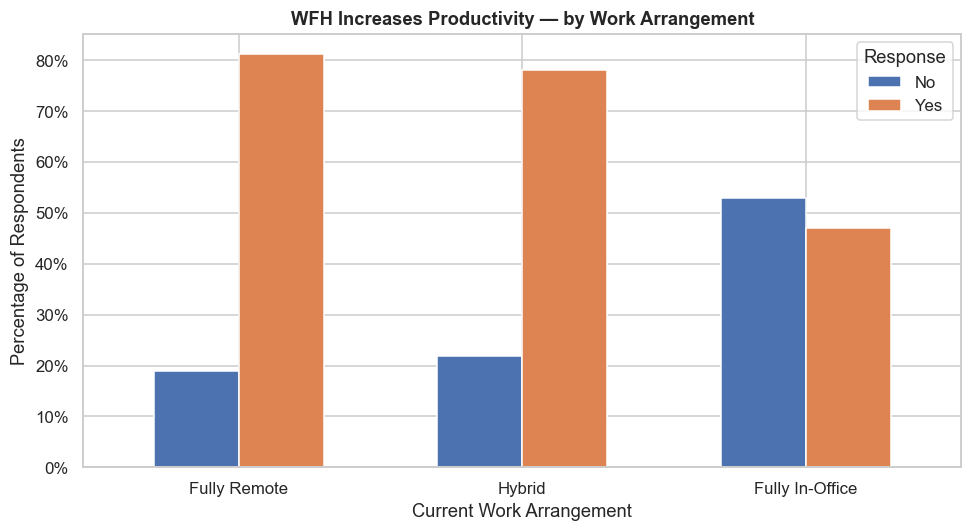

Do you think that working from home increases your work productivity?,No,Yes
Current Work Arrangement,,
Fully Remote,18.9,81.1
Hybrid,21.8,78.2
Fully In-Office,53.0,47.0


In [6]:
col = 'Do you think that working from home increases your work productivity?'
ct = pd.crosstab(df['Current Work Arrangement'], df[col], normalize='index') * 100
ct = ct.reindex(arr_order)

ax = ct.plot(kind='bar', figsize=(9, 5), color=['#4C72B0', '#DD8452'],
             edgecolor='white', width=0.6)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Current Work Arrangement')
ax.set_ylabel('Percentage of Respondents')
ax.set_title('WFH Increases Productivity — by Work Arrangement', fontweight='bold')
ax.legend(title='Response')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()
display(ct.round(1))

### 5b. Work Preference by Industry

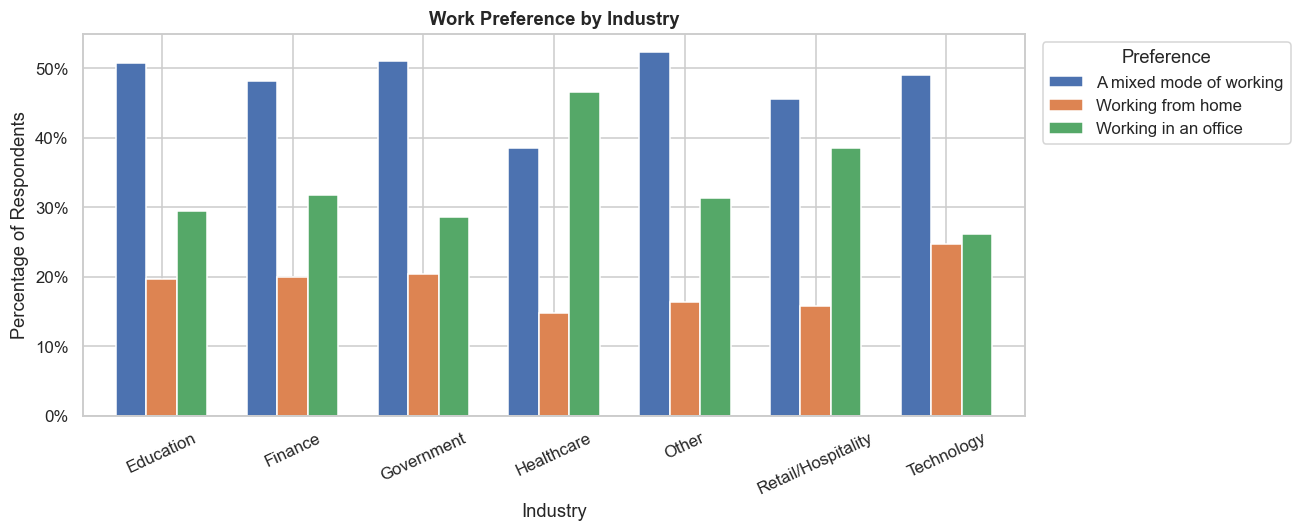

Which work type do you prefer the most?,A mixed mode of working,Working from home,Working in an office
Industry,,,
Education,50.8,19.7,29.5
Finance,48.1,20.0,31.9
Government,51.0,20.4,28.6
Healthcare,38.5,14.9,46.6
Other,52.4,16.3,31.3
Retail/Hospitality,45.6,15.8,38.6
Technology,49.1,24.8,26.1


In [7]:
col = 'Which work type do you prefer the most?'
ct = pd.crosstab(df['Industry'], df[col], normalize='index') * 100

ax = ct.plot(kind='bar', figsize=(12, 5), color=['#4C72B0', '#DD8452', '#55A868'],
             edgecolor='white', width=0.7)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Industry')
ax.set_ylabel('Percentage of Respondents')
ax.set_title('Work Preference by Industry', fontweight='bold')
ax.legend(title='Preference', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()
display(ct.round(1))

### 5c. Focus by Age Group

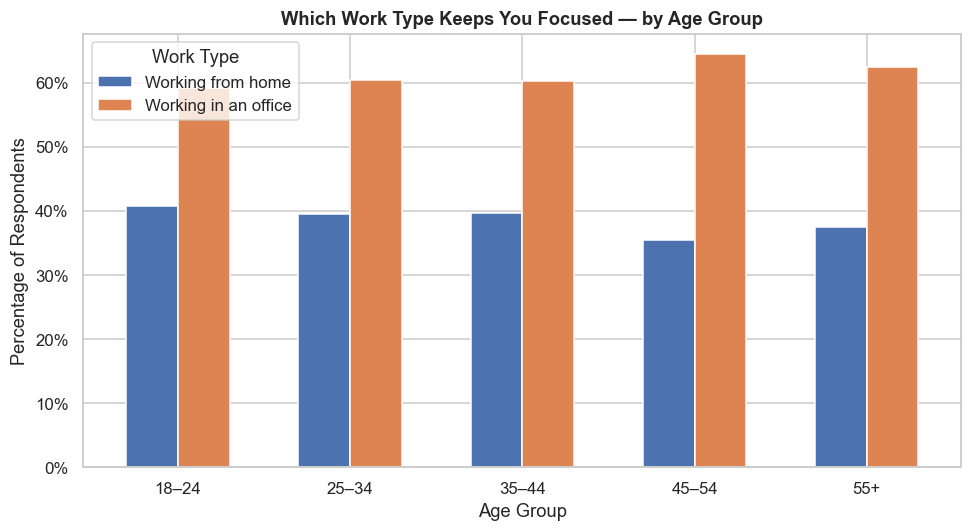

Which work type keeps you focused while working?,Working from home,Working in an office
Age Group,,
18–24,40.8,59.2
25–34,39.6,60.4
35–44,39.7,60.3
45–54,35.6,64.4
55+,37.5,62.5


In [8]:
col = 'Which work type keeps you focused while working?'
ct = pd.crosstab(df['Age Group'], df[col], normalize='index') * 100
ct = ct.reindex(age_order)

ax = ct.plot(kind='bar', figsize=(9, 5), color=['#4C72B0', '#DD8452'],
             edgecolor='white', width=0.6)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Age Group')
ax.set_ylabel('Percentage of Respondents')
ax.set_title('Which Work Type Keeps You Focused — by Age Group', fontweight='bold')
ax.legend(title='Work Type')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()
display(ct.round(1))

### 5d. Physical & Mental Health Risks by Work Arrangement

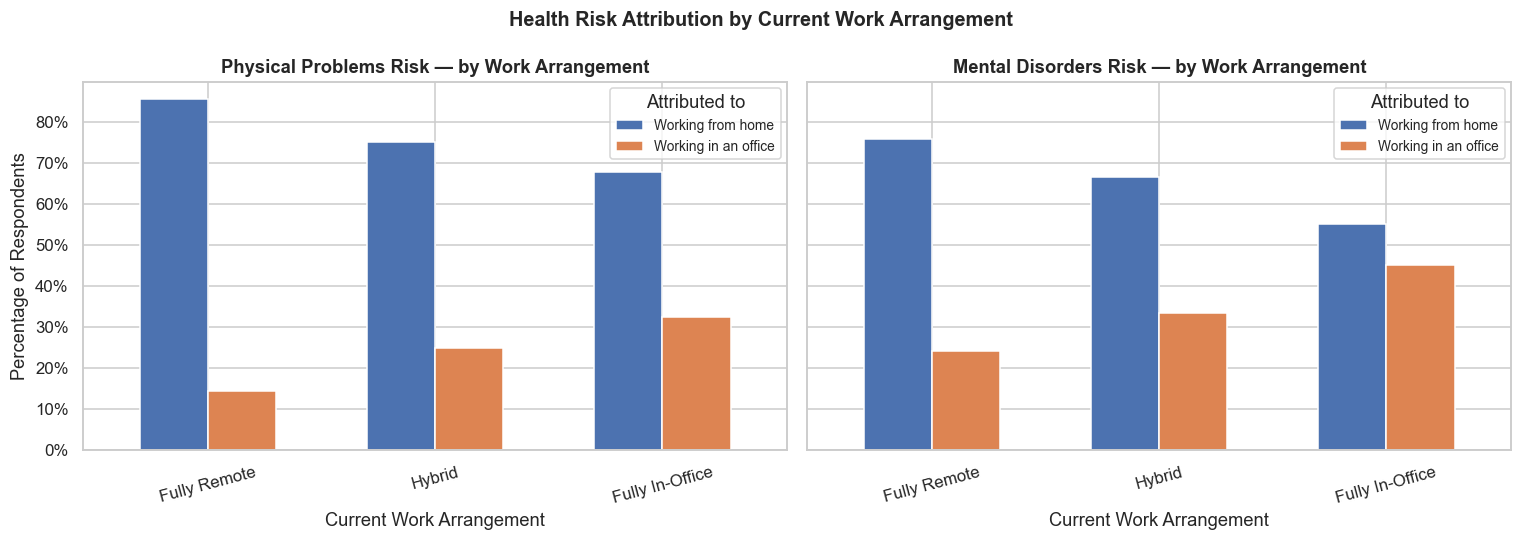

In [9]:
health_cols = [
    ('Which work type has the potential to cause you physical problems, such as the neck, back, and leg pain?', 'Physical Problems'),
    ('Which work type has the potential to cause mental disorders, such as stress, anxiety, and depression?',   'Mental Disorders'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (col, label) in zip(axes, health_cols):
    ct = pd.crosstab(df['Current Work Arrangement'], df[col], normalize='index') * 100
    ct = ct.reindex(arr_order)
    ct.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.6)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(f'{label} Risk — by Work Arrangement', fontweight='bold')
    ax.set_xlabel('Current Work Arrangement')
    ax.set_ylabel('Percentage of Respondents')
    ax.legend(title='Attributed to', fontsize=9)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Health Risk Attribution by Current Work Arrangement', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5e. Social Isolation by Work Arrangement

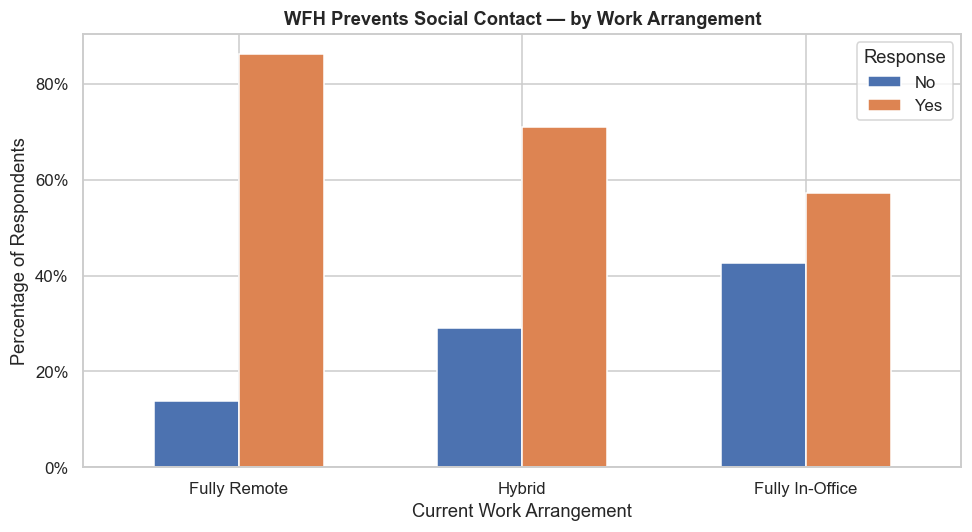

Do you think that working from home prevents you from getting in contact with people?,No,Yes
Current Work Arrangement,,
Fully Remote,13.8,86.2
Hybrid,29.0,71.0
Fully In-Office,42.7,57.3


In [10]:
col = 'Do you think that working from home prevents you from getting in contact with people?'
ct = pd.crosstab(df['Current Work Arrangement'], df[col], normalize='index') * 100
ct = ct.reindex(arr_order)

ax = ct.plot(kind='bar', figsize=(9, 5), color=['#4C72B0', '#DD8452'],
             edgecolor='white', width=0.6)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Current Work Arrangement')
ax.set_ylabel('Percentage of Respondents')
ax.set_title('WFH Prevents Social Contact — by Work Arrangement', fontweight='bold')
ax.legend(title='Response')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()
display(ct.round(1))

---
## 6. Preference Deep-Dive

### 6a. Preference by Age Group

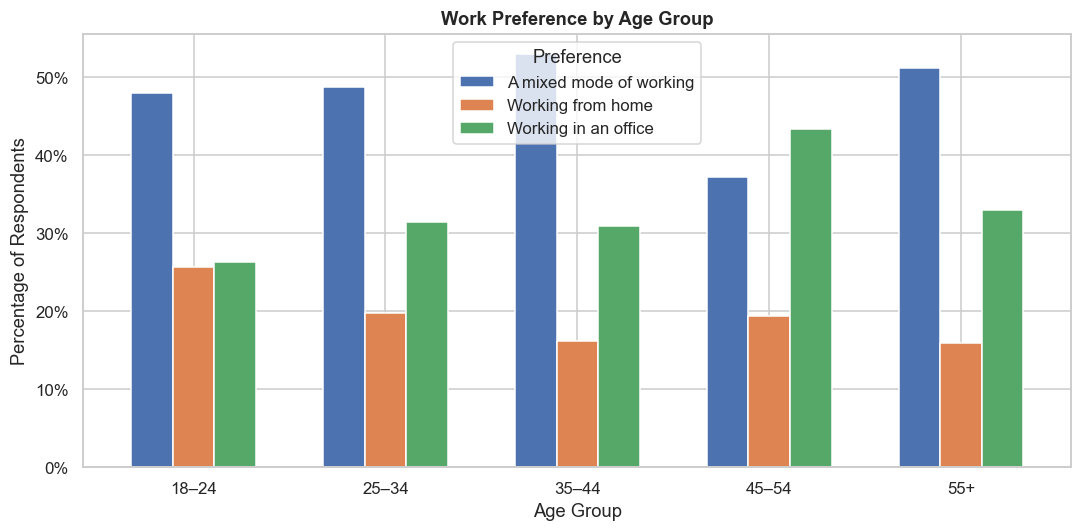

Which work type do you prefer the most?,A mixed mode of working,Working from home,Working in an office
Age Group,,,
18–24,48.0,25.7,26.3
25–34,48.7,19.8,31.5
35–44,52.9,16.2,30.9
45–54,37.2,19.4,43.3
55+,51.1,15.9,33.0


In [11]:
col = 'Which work type do you prefer the most?'
ct = pd.crosstab(df['Age Group'], df[col], normalize='index') * 100
ct = ct.reindex(age_order)

ax = ct.plot(kind='bar', figsize=(10, 5), color=['#4C72B0', '#DD8452', '#55A868'],
             edgecolor='white', width=0.65)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Age Group')
ax.set_ylabel('Percentage of Respondents')
ax.set_title('Work Preference by Age Group', fontweight='bold')
ax.legend(title='Preference')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()
display(ct.round(1))

### 6b. Preference by Gender

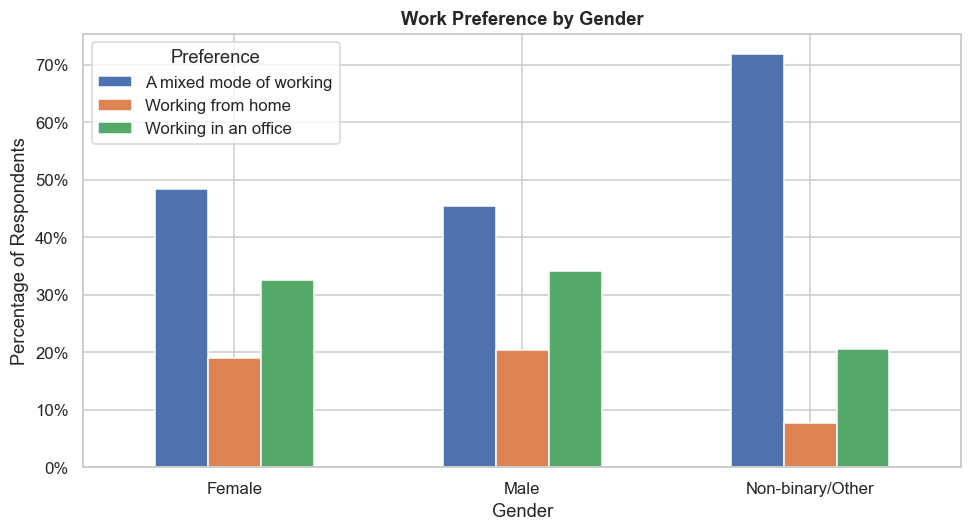

Which work type do you prefer the most?,A mixed mode of working,Working from home,Working in an office
Gender,,,
Female,48.4,19.1,32.5
Male,45.5,20.5,34.1
Non-binary/Other,71.8,7.7,20.5


In [12]:
col = 'Which work type do you prefer the most?'
ct = pd.crosstab(df['Gender'], df[col], normalize='index') * 100

ax = ct.plot(kind='bar', figsize=(9, 5), color=['#4C72B0', '#DD8452', '#55A868'],
             edgecolor='white', width=0.55)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Gender')
ax.set_ylabel('Percentage of Respondents')
ax.set_title('Work Preference by Gender', fontweight='bold')
ax.legend(title='Preference')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()
display(ct.round(1))

### 6c. Heatmap — Preference vs. All Survey Questions

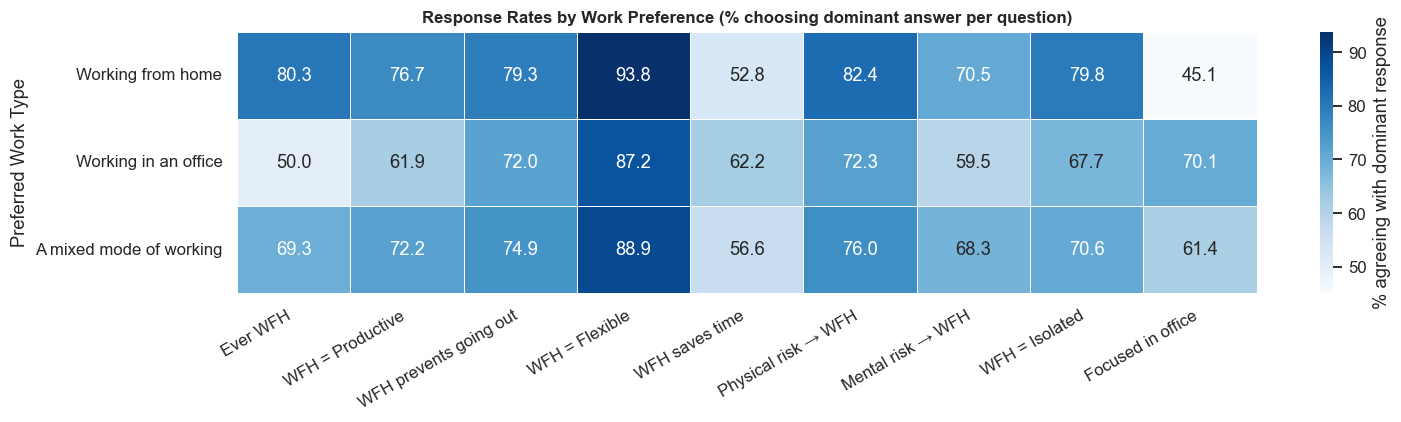

In [13]:
pref_col = 'Which work type do you prefer the most?'
short_labels = [
    'Ever WFH',
    'WFH = Productive',
    'WFH prevents going out',
    'WFH = Flexible',
    'WFH saves time',
    'Physical risk → WFH',
    'Mental risk → WFH',
    'WFH = Isolated',
    'Focused in office',
]
binary_cols = survey_cols[:-1]  # all but preference itself
pref_order = ['Working from home', 'Working in an office', 'A mixed mode of working']

heat_data = {}
for col, short in zip(binary_cols, short_labels):
    positive_val = df[col].value_counts().idxmax()  # most common value
    ct = pd.crosstab(df[pref_col], df[col], normalize='index') * 100
    if positive_val in ct.columns:
        heat_data[short] = ct[positive_val]

heat_df = pd.DataFrame(heat_data).reindex(pref_order)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(heat_df, annot=True, fmt='.1f', cmap='Blues', linewidths=0.5,
            cbar_kws={'label': '% agreeing with dominant response'}, ax=ax)
ax.set_title('Response Rates by Work Preference (% choosing dominant answer per question)',
             fontweight='bold', fontsize=11)
ax.set_ylabel('Preferred Work Type')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## 7. Summary Findings

### Flexibility & Productivity
- **91%** of respondents believe WFH offers greater flexibility — near-universal agreement regardless of industry or age.
- **70%** believe WFH increases productivity, with the strongest agreement among fully-remote workers and those in Technology. Fully in-office workers are more sceptical (~50%).

### Time & Social Trade-offs
- Only **42%** think WFH saves time, suggesting commute savings are offset by blurred work–life boundaries or inefficiencies at home.
- **70%** feel WFH limits social contact, and **75%** believe it reduces physical activity (going out).

### Health Risks
- **76%** attribute greater physical health risks (neck/back/leg pain) to WFH — consistent with sedentary, often poorly-ergonomic home setups.
- **66%** attribute greater mental health risks to WFH, reflecting concerns around isolation and blurred boundaries. Office stress (management, commuting) is cited by the remaining 34%.

### Focus
- **61%** find the office better for focus - though this varies with age (older workers prefer office more) and arrangement (remote workers tilt toward WFH focus).

### Preferences
- **48%** prefer a **hybrid** model — the clear plurality choice across all demographics.
- **33%** prefer the **office**, **19%** prefer **fully remote** work.
- Technology workers lean more remote; Healthcare and Retail workers lean more office.
- Older respondents (45+) disproportionately prefer office or hybrid arrangements.

### Recommendation
The data points strongly toward hybrid work as the optimal model: it preserves the flexibility and productivity benefits of WFH while mitigating health risks and maintaining the social connection and focus advantages of in-office work.